# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Adelle Solange Naa Ayele Hammond]
**Student ID:** [72942028]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

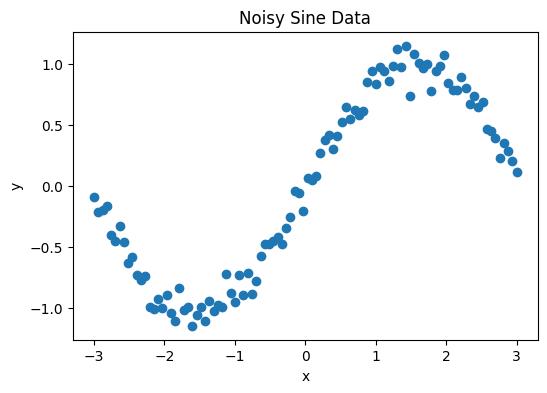

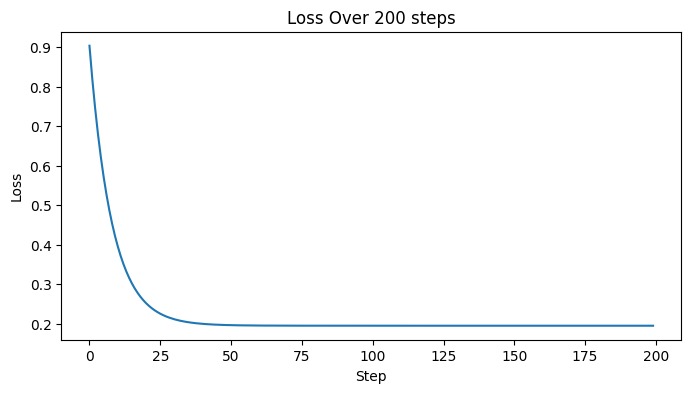

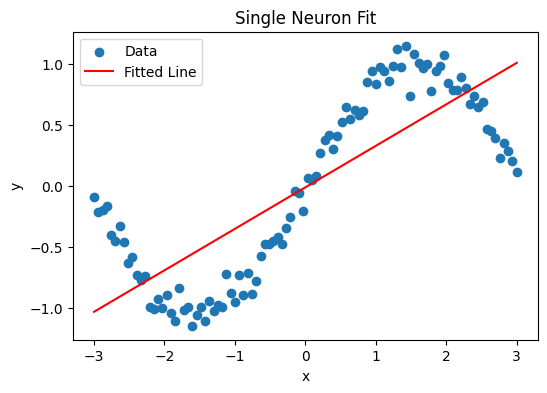

In [2]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape) 

plt.figure(figsize=(6,4))
plt.scatter(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy Sine Data")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
lr = 0.01

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
losses = []

for i in range(200):
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)               # MSE
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    -= lr * dw
    b    -= lr * db

    losses.append(loss)


# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.figure(figsize=(8,4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Over 200 steps")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, w*x + b, color="red", label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Single Neuron Fit")
plt.show()


**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** The model is underfitting because it is too simple to represent the data and a single neuron can only learn a linear function of form y = wx + b. A sine wave is a nonlinear function with curves and no matter how long the model is trained it can only produce a best fitting straight(linear) line.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

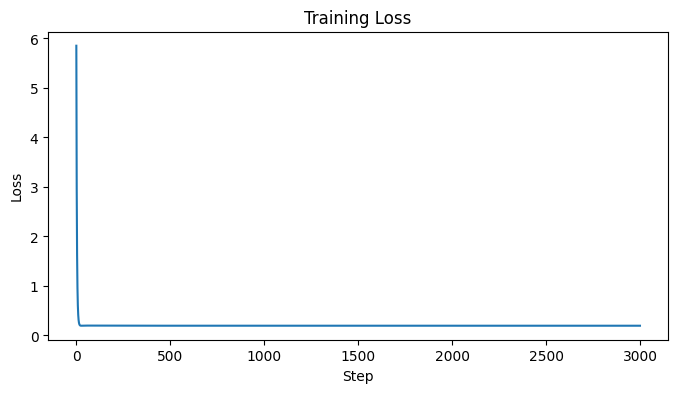

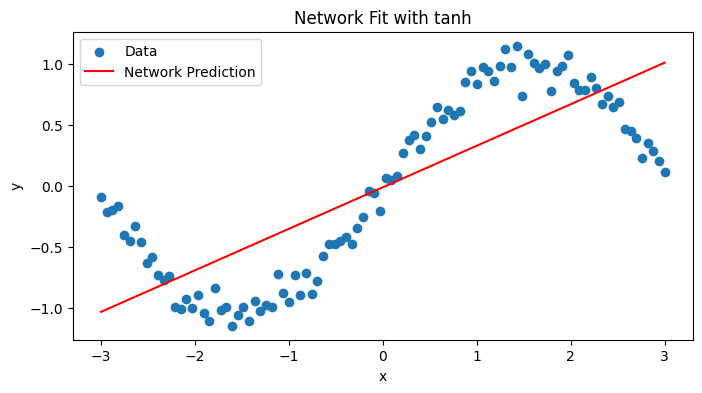

In [3]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

np.random.seed(42)

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

for i in range(3000):
    z1 = x @ W1 + b1
    h  = z1       
    y_hat = h @ W2 + b2     
    loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat  
    db2 = d_yhat.sum(axis=0)

    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh

    dW1 = x.T @ dz1 
    db1 = dz1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(8,4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Network Prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Network Fit with tanh")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** With the tanh removed it makes the layers become one, because without the activation, mathematically output = ((x · W1) + b1) · W2 + b2 and after you multiply a factor out it becomes x · (W1 · W2) + (b1 · W2 + b2) which translates to exactly x · a single weight + a single bias. Therefore no matter how many layers you put together, you will still get a straight line.                  
With tanh, each neuron turns x into a curved line and the final output combines these 8 different curved lines, thereby building a wavy shape out of simple bent pieces.
That’s why the network can now fit the wavy data and without tanh, all features are just straight lines, and you can't build a curve from straight lines.  
Backpropagation is when the chain rule runs backward through a network to figure out how much each weight should change, so that the loss gets smaller.                                                   

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_20041/3172605295.py:17: RuntimeWarning: overflow encountered in square
  loss  = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_20041/3172605295.py:23: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/tmp/ipykernel_20041/3172605295.py:24: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


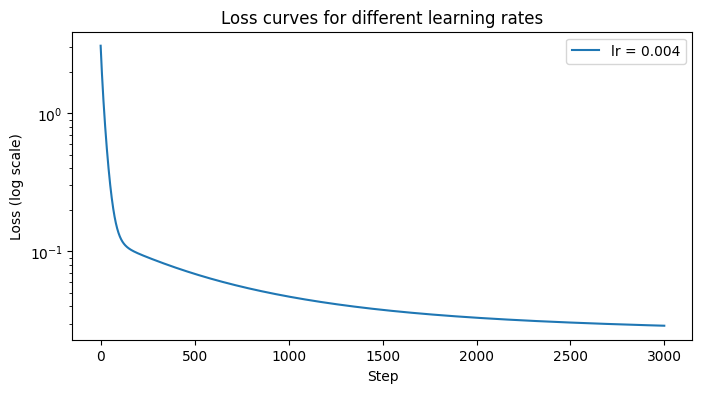

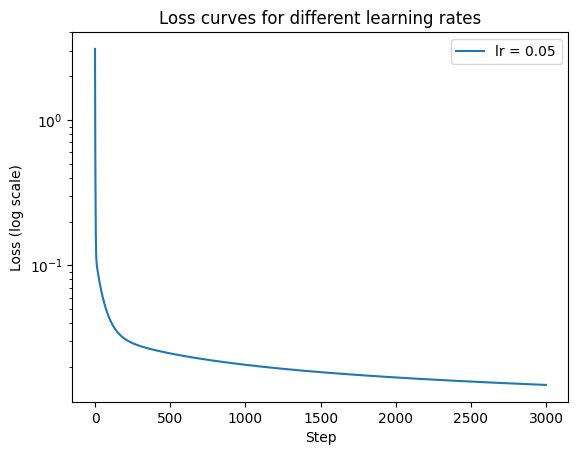

/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


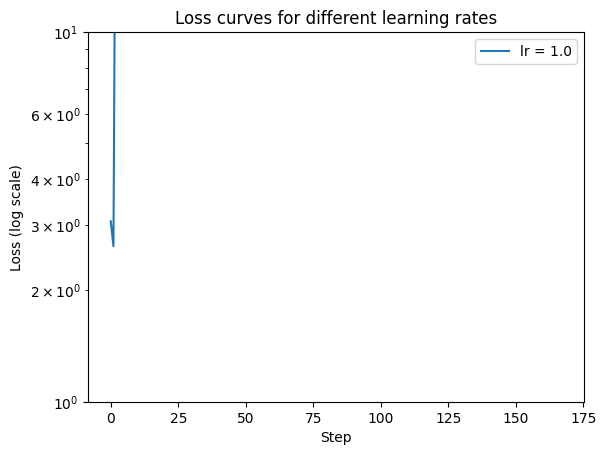

In [4]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):
    np.random.seed(42)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses=[]

    for i in range(steps):
        # Forward pass
        z1 = x @ W1 + b1
        h  = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss  = np.mean((y_hat - y) ** 2)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Parameter update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        losses.append(loss)
    return losses


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
lrs = [0.004, 0.05, 1.0]
all_losses = {}
for lr in lrs:
    all_losses[lr] = train_toy(lr, steps=3000)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8,4))

for lr in lrs:
    plt.plot(all_losses[lr], label=f'lr = {lr}')
    plt.yscale('log')                
    plt.xlabel('Step')
    plt.ylabel('Loss (log scale)')
    plt.title('Loss curves for different learning rates')
    plt.legend()
    plt.show()


**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** The curve that has a small learning rate of 0.004, shows how the loss goes down slowly and staedily and because the network is learning, 3000 steps still isn't even enough to reach the bottom.                                                                                                                                The curve  that has a medium learning rate of 0.05, shows how the loss drops quickly and smoothly to a small value and it is a good rate because its large enough to make quick progress but small enough to stay stable and not explode.                                                                                                                                The curve that has the large learning rate of 1.0, shows that the loss does not go down but shoots up to an extremely large numbers which means that the network is exploding.                                                                                                                               A large learning rate does not make the model learn faster because gradient descent takes small steps towards the minimum and when the steps are too large, each update can jump past the optimal point to the other side of the loss surface. This causes the parameters to bounce back and forth, leading to oscillations and if the updates become extremely large, the errors grow instead of shrink, causing the loss to explode and preventing the model from converging.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [5]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
obesity = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv")


# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
from sklearn.preprocessing import LabelEncoder

obesity_encoded = obesity.copy()
binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]
for col in binary_cols:
    obesity_encoded[col] = obesity_encoded[col].map({
        "yes": 1,
        "no": 0
    })
categorical_cols = [
    "Gender",
    "CAEC",
    "CALC",
    "MTRANS"
]
obesity_encoded = pd.get_dummies(
    obesity_encoded,
    columns=categorical_cols,
    drop_first=True
)

label_encoder = LabelEncoder()
obesity_encoded["NObeyesdad"] = label_encoder.fit_transform(
    obesity_encoded["NObeyesdad"]
)

X = obesity_encoded.drop("NObeyesdad", axis=1)
y = obesity_encoded["NObeyesdad"]

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,   
    stratify=y_train_val,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train shape: (1266, 23)
Validation shape: (422, 23)
Test shape: (423, 23)
Training batches: 40
Validation batches: 14
Test batches: 14


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** CrossEntropyLoss in PyTorch needs integer class labels because it is designed to compare the model’s predicted class probabilities with the correct class index. Instead of using one-hot vectors, PyTorch expects a single number representing the correct class, such as 0, 1, or 2 and this makes the calculation more efficient because the loss function already handles the softmax operation internally.

Neural networks use gradient‑based updates where the gradient is directly proportional to the input values, as seen in the formula dw = np.mean(2 * (y_hat - y) * x). If the features have different scales, the weights connected to large scale features receive larger gradient updates, while those for small scale features barely change. This imbalance warps the loss surface, leading to converging happening very slowly, therefore standardising features puts all inputs on a similar scale, producing balanced gradients and stable training. Random forests, rather simply compare values to thresholds and scaling does not change the ordering, so the splits stay identical and no gradient instability happens.

Shuffle=True randomises the order of training examples in each small batches at the start of every epoch, since without shuffling, the model would see long sequences of samples from the same class and can give biased gradient estimates that stop convergence.


### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [6]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet,self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(hidden_sizes[1], n_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        logits = self.output(x)
        return logits

# TODO: Instantiate, move to DEVICE, print the model.

input_dim = X_train.shape[1] 
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_parameter = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_parameter}")

first_layer_hand_parameter = (input_dim * 64) + 64
print(f"Hand calculation of first layer parameters: {first_layer_hand_parameter}")

first_layer_actual_parameter = sum(p.numel() for p in model.fc1.parameters() if p.requires_grad)
print(f"Actual first layer parameters: {first_layer_actual_parameter}")


FeedForwardNet(
  (fc1): Linear(in_features=23, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=32, out_features=7, bias=True)
)
Total trainable parameters: 3847
Hand calculation of first layer parameters: 1536
Actual first layer parameters: 1536


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** Layer 1 is (23 inputs x 64 nodes) + 64 biases = 1536
Layer 2 is (64 inputs x 32 nodes) + 32 biases = 2080
Output layer is (32 inputs x 7 nodes) + 7 biases = 231
Total is 1536 + 2080 + 231 = 3847, which perfectly matches PyTorch.

ReLU was used because when its used the gradient doesn't flatten out to zero for positive numbers and so the network is able to learn faster and doesn't get stuck during backpropagation

Without the ReLU, the network would just compute one big linear transformation because without non-linear activation functions putting multiple layers together becomes into a single linear layer.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 1.8897, Train Acc: 0.3207 | Val Loss: 1.7961, Val Acc: 0.5640
Epoch 02/50 | Train Loss: 1.6546, Train Acc: 0.6043 | Val Loss: 1.4679, Val Acc: 0.5948
Epoch 03/50 | Train Loss: 1.2662, Train Acc: 0.6161 | Val Loss: 1.1027, Val Acc: 0.6351
Epoch 04/50 | Train Loss: 0.9777, Train Acc: 0.6959 | Val Loss: 0.9113, Val Acc: 0.7227
Epoch 05/50 | Train Loss: 0.8173, Train Acc: 0.7393 | Val Loss: 0.8068, Val Acc: 0.7204
Epoch 06/50 | Train Loss: 0.7054, Train Acc: 0.7536 | Val Loss: 0.7235, Val Acc: 0.7725
Epoch 07/50 | Train Loss: 0.6175, Train Acc: 0.8049 | Val Loss: 0.6600, Val Acc: 0.7536
Epoch 08/50 | Train Loss: 0.5455, Train Acc: 0.8325 | Val Loss: 0.5998, Val Acc: 0.8057
Epoch 09/50 | Train Loss: 0.4870, Train Acc: 0.8476 | Val Loss: 0.5530, Val Acc: 0.8223
Epoch 10/50 | Train Loss: 0.4284, Train Acc: 0.8705 | Val Loss: 0.5102, Val Acc: 0.8318
Epoch 11/50 | Train Loss: 0.3785, Train Acc: 0.8870 | Val Loss: 0.4793, Val Acc: 0.8270
Epoch 12/50 | Train Loss: 0.3394

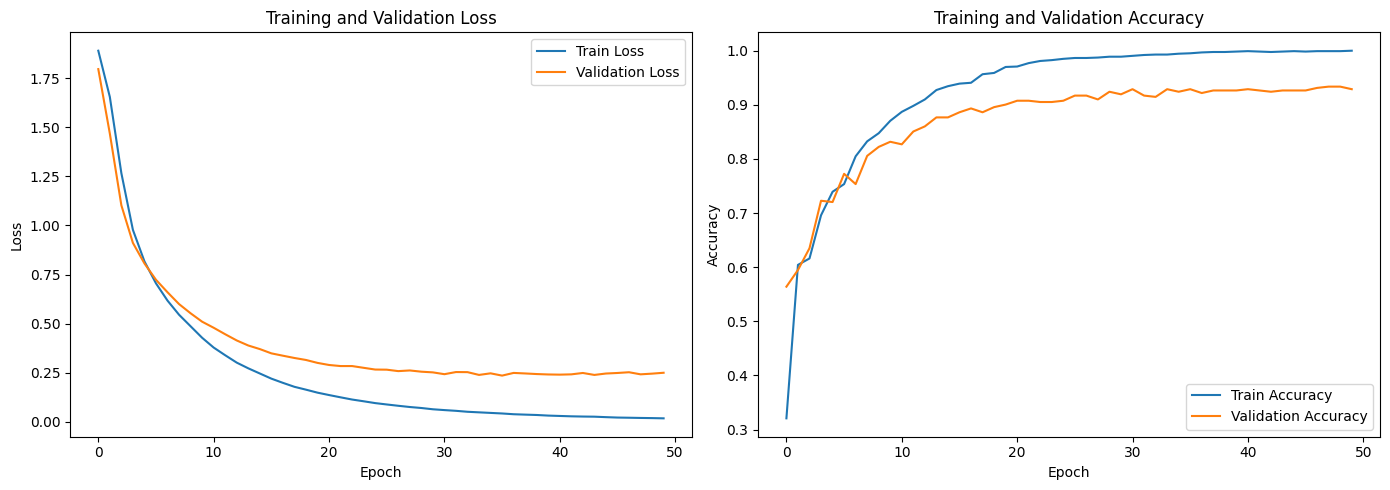

In [7]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # We used Adam because Adam automatically adapts the 
# learning rate for each parameter during training and this results in faster and more stable convergence, 
# thereby avoiding the need to manually tune momentum.

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

epochs = 50

train_losses = []
train_accuracy = []
val_losses = []
val_accuracy = []

best_val_accuracy = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct_train = 0
    total_train = 0
    
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()  
        optimizer.step() 
        
        running_loss += loss.item() * xb.size(0)
        _, preds = torch.max(logits, 1)
        correct_train += (preds == yb).sum().item()
        total_train += yb.size(0)
        
    epoch_train_loss = running_loss / total_train
    epoch_train_accuracy = correct_train / total_train
    
    # validation
    model.eval()
    running_val_loss = 0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            
            logits = model(xb)
            loss = criterion(logits, yb)
            
            running_val_loss += loss.item() * xb.size(0)
            _, preds = torch.max(logits, 1)
            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_accuracy = correct_val / total_val
    
    # 3. Append to history lists and print
    train_losses.append(epoch_train_loss)
    train_accuracy.append(epoch_train_accuracy)
    val_losses.append(epoch_val_loss)
    val_accuracy.append(epoch_val_accuracy)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label="Train Accuracy")
plt.plot(val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** Forward pass is logits = model(xb) maps to the math: y_hat = h @ W2 + b2. Compute gradients is loss.backward() maps to the chain rule math: dW2 = h.T @ d_yhat and the update rule is optimizer.step() maps to subtracting the gradients: W1 -= lr * dW1. The model is overfitting because the training accuracy curve continues climbing until it reaches 1 (100%), while the validation accuracy slows down and plateaus around 0.93 (93%). At the same time, a clear gap forms in the loss curves after epoch 20, where the training loss continues dropping down to nearly 0, but the validation loss stops improving and flattens out around 0.25.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

Experiment A (Capacity): 


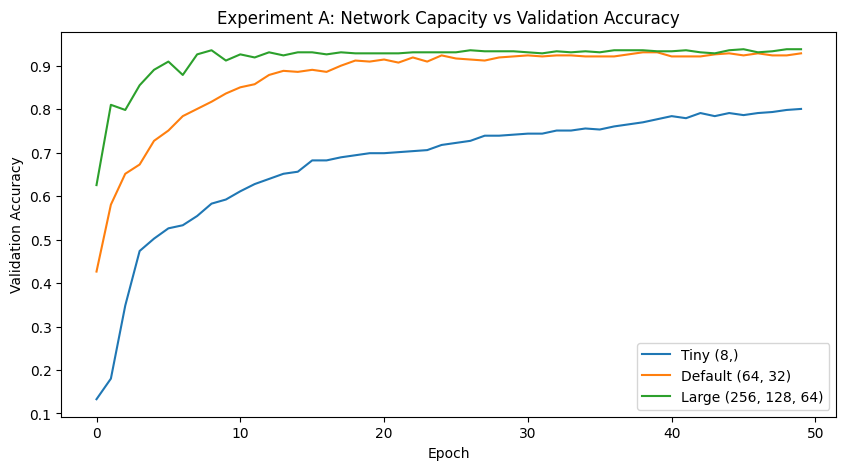

Experiment B (Learning Rate): 


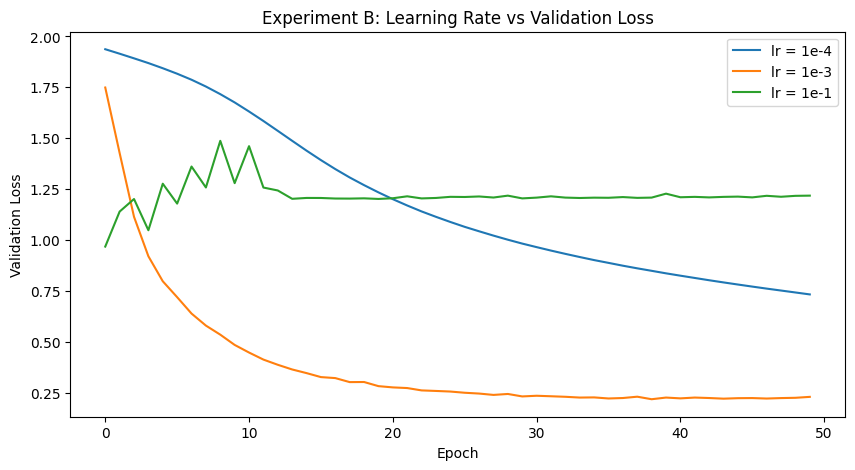

Experiment C (Regularization): 


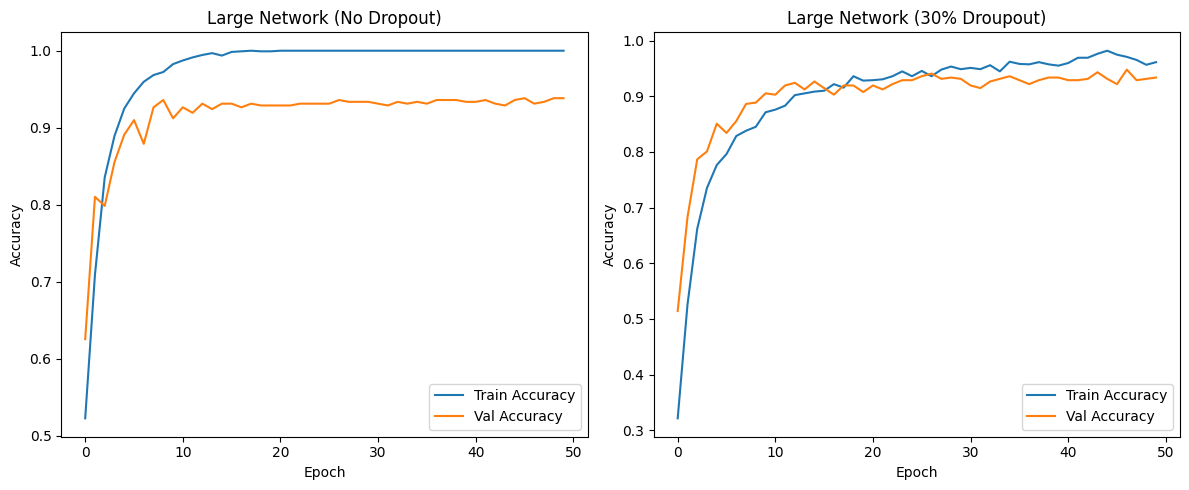

In [8]:
class DynamicFeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0):
        super(DynamicFeedForwardNet, self).__init__()
        
        layers = []
        in_size = input_dim
        
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_size = h
            
        self.hidden_layers = nn.Sequential(*layers)
        self.output = nn.Linear(in_size, n_classes)

    def forward(self, x):
        x = self.hidden_layers(x)
        return self.output(x)

# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0):
    exp_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    exp_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    input_dim = X_train.shape[1] 
    model = DynamicFeedForwardNet(input_dim, hidden_sizes, n_classes=7, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct_train = 0
        total_train = 0
        
        for xb, yb in exp_train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()  
            optimizer.step() 
            
            running_loss += loss.item() * xb.size(0)
            _, preds = torch.max(logits, 1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.size(0)

        model.eval()
        running_val_loss = 0
        correct_val = 0
        total_val = 0
            
        with torch.no_grad():
            for xb, yb in exp_val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                    
                logits = model(xb)
                loss = criterion(logits, yb)
                    
                running_val_loss += loss.item() * xb.size(0)
                _, preds = torch.max(logits, 1)
                correct_val += (preds == yb).sum().item()
                total_val += yb.size(0)

        history['train_loss'].append(running_loss/total_train)
        history['train_accuracy'].append(correct_train/total_train)
        history['val_loss'].append(running_val_loss/total_val)
        history['val_accuracy'].append(correct_val/total_val)

    return history
                

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
print("Experiment A (Capacity): ")
tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64, 32))
large = run_experiment(hidden_sizes=(256, 128, 64))

plt.figure(figsize=(10, 5))
plt.plot(tiny['val_accuracy'], label='Tiny (8,)')
plt.plot(default['val_accuracy'], label='Default (64, 32)')
plt.plot(large['val_accuracy'], label='Large (256, 128, 64)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Experiment A: Network Capacity vs Validation Accuracy')
plt.legend()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
print("Experiment B (Learning Rate): ")
lr_low = run_experiment(lr=1e-4)
lr_med = run_experiment(lr=1e-3)
lr_high = run_experiment(lr=1e-1)

plt.figure(figsize=(10, 5))
plt.plot(lr_low['val_loss'], label='lr = 1e-4')
plt.plot(lr_med['val_loss'], label='lr = 1e-3')
plt.plot(lr_high['val_loss'], label='lr = 1e-1')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Experiment B: Learning Rate vs Validation Loss')
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
print("Experiment C (Regularization): ")
large_droupout = run_experiment(hidden_sizes=(256,128,64),dropout=0.3)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(large['train_accuracy'], label='Train Accuracy')
plt.plot(large['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Large Network (No Dropout)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(large_droupout['train_accuracy'], label='Train Accuracy')
plt.plot(large_droupout['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Large Network (30% Droupout)')
plt.legend()

plt.tight_layout()
plt.show()


**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?* 
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** 1. The largest network technically won but by a very small margin and it looks like the large network was overtrained and so the validation accuracy peaked and stayed the same while the default network got better as time went on . Diminishing returns can be seen when moving from default network to the large network and the improvement in the validation accuracy is smaller compared to the improvement in validation accuracy from tiny to default. Overfitting can be seen when the training accuracy increases but the validation accuracy stops improving.                                                                        2. Yes the three regimes match what I saw on the toy problem in Part 1.3. The curve lr = 1e-4 matches the 0.004 curve from Part 1.3, showing that the validation loss decreases slowly and steadily but even after many steps it hasn't reached the bottom yet . The curve lr = 1e-3 matches the 0.05 curve from Part 1.3 , showing that the validation loss drops quickly and smoothly to a low value, thereby showing that the network is stable. The curve lr = 1e-1 matches the 0.1 curve from Part 1.3 , showing that the validation loss explodes to big numbers showing that the network is unstable.                                                                         3. Droupout narrowed the gap by reducing the training accuracy while validation accuracy remained the same or was slightly improved and dropout did this by randomly deactivating 0.3 of neurons per pass which forces the network to learn redundant, independent features which leads to the model generalizing better

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9078
Test Macro-F1: 0.9063

Classification Report: 

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.83      0.86      0.85        58
     Obesity_Type_I       0.88      0.99      0.93        70
    Obesity_Type_II       0.98      0.92      0.95        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.81      0.81      0.81        58
Overweight_Level_II       0.87      0.83      0.85        58

           accuracy                           0.91       423
          macro avg       0.91      0.90      0.91       423
       weighted avg       0.91      0.91      0.91       423



<Figure size 1000x800 with 0 Axes>

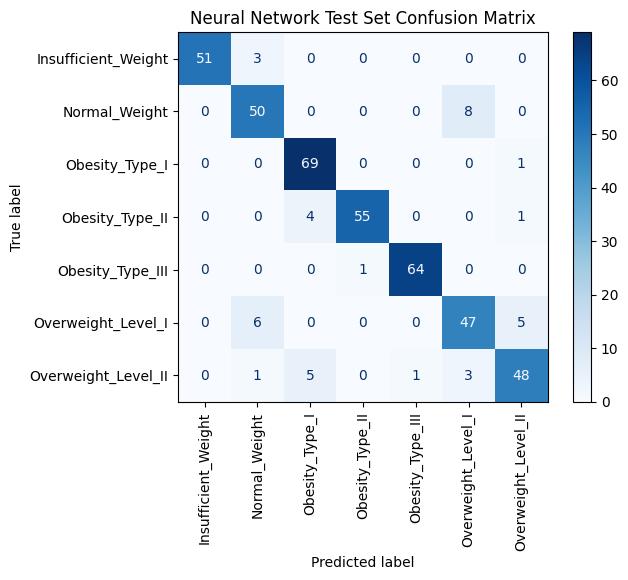

,Model,Test Accuracy,Test Macro-F1,Training Time,Complexity
0,Lab 2 (Random Forest),0.978700,0.978300,~2 seconds,100 Trees
1,Lab 3 (Neural Network),0.907801,0.906302,~15 seconds,"3,847 Parameters"


In [9]:
# TODO: Load your best configuration's weights; model.eval().
input_dim = X_train.shape[1]
model = FeedForwardNet(input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()

predictions = []
targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        _, preds = torch.max(logits, 1)
        
        predictions.extend(preds.cpu().numpy())
        targets.extend(yb.numpy())

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, classification_report

test_accuracy = accuracy_score(targets,predictions)
test_f1 = f1_score(targets, predictions, average='macro')

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")
print("\nClassification Report: \n")
print(classification_report(targets, predictions, target_names=label_encoder.classes_))

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    targets, 
    predictions, 
    display_labels=label_encoder.classes_, 
    xticks_rotation='vertical', 
    cmap='Blues'
)
plt.title("Neural Network Test Set Confusion Matrix")
plt.show()


# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison_table = {
    "Model": ["Lab 2 (Random Forest)", "Lab 3 (Neural Network)"],
    "Test Accuracy": [0.9787, test_accuracy], 
    "Test Macro-F1": [0.9783, test_f1],
    "Training Time": ["~2 seconds", "~15 seconds"], 
    "Complexity": ["100 Trees", "3,847 Parameters"]
}

comparison_df = pd.DataFrame(comparison_table)
display(comparison_df)


**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** 1. The network still confuses adjacent categories, specifically the Normal Weight with Overweight Level I, and Overweight Level I with Level II and these are the same categories the Lab 2 Random Forest struggled with, because patients in these borderline classes share very similar physical metrics and eating habits.                                                        2. The Random Forest is the winner, achieving much higher accuracy in a fraction of the training time, therefore the extra effort of deep learning was not worth it here, as tree based models naturally work well on small, structured tabular datasets. Deep learning is better suited for big datasets or unstructured data like images, audio, and text.

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** 1. The black box, opened: loss.backward() is used to calculate gradients through backpropagation in order to find out how much error each weight contributes  and optimizer.step() uses gradients that have been scaled by learning rates to update weights and help minimize loss.                                                         2. Hyperparameters: I would select the learning rate because it helps control the size of the step during gradient descent, for example high step sizes causes the model to explode or diverge while very low steps causes to learn and train to slowly.                                                       3. Overfitting: The large model overfit the most because it had the biggest train vs validation gap and so by adding Dropout, it fixed this by randomly disabling neurons, forcing the network to learn robust, general features instead.                                                      4. Looking ahead: A plain MLP flattens images into 1D arrays, which completely ruins the spatial relationships between neighboring pixels and so a  better architecture needs local connectivity (like Convolutional Neural Networks) to recognize shapes and textures regardless of their exact location.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.